# Shuttle-Bus Headway Analysis — Member 1

**Paper:** T. Nagatani, *Chaos control and schedule of shuttle buses*, Physica A 371 (2006) 683-691.

**Task:** Analyze the headway $H_1(m)$ of bus 1 versus the loading parameter $\Gamma$ for four speedup configurations, reproduce **Fig. 2** and **Fig. 3**, and explain how speedup damps headway oscillations and why the system becomes irregular as $\Gamma$ grows.

| Case | $S_1$ | $S_2$ |
|---|---|---|
| (a) | 0   | 0   |
| (b) | 0.2 | 0.2 |
| (c) | 0.3 | 0.2 |
| (d) | 0.5 | 0.2 |


## 1. Nonlinear map model

$M$ shuttle buses run between an **origin** and a **destination**, passing each other freely. Arrival time of bus $i$ at the origin (Eq. 1):

$$t_i(m+1) = t_i(m) + (\gamma+\eta)\,B_i(m) + \frac{2L}{V_i(m)}$$

Boarding passengers accumulate since the previous bus left (Eq. 2): $B_i(m) = \mu\,(t_i(m) - t_{i'}(m'))$, where $i'$ is the bus that reached the origin just before bus $i$.

Buses speed up in proportion to the boarding delay (Eq. 3): $V_i(m) = V_0 + s_i(\gamma+\eta)B_i(m)$.

Scaling time by $2L/V_0$ and defining $T_i \equiv t_iV_0/2L$, $\ \Gamma \equiv \mu(\gamma+\eta)$, $\ S_i \equiv s_i\mu(\gamma+\eta)\,2L/V_0^2$ gives the dimensionless map (Eq. 5):

$$\boxed{\,T_i(m+1) = T_i(m) + \Gamma\,H_i + \frac{1}{1 + S_i\,H_i}\,},\qquad H_i = T_i(m) - T_{i'}(m')$$

- $\Gamma$ — **loading parameter** (large $\Gamma$ = more passengers = longer stops).
- $S_i$ — **speedup parameter** of bus $i$.

The stop term $\Gamma H_i$ is **positive feedback** (larger headway -> longer stop -> larger headway). The run term $1/(1+S_iH_i)$ **decreases** with $H_i$ — **negative feedback** that pulls the headway back. This competition is the whole story.


## 2. Simulation

Because buses pass freely, the model is iterated **event-driven**: at each step the bus with the smallest arrival time arrives next, and its headway is its arrival time minus the previous event's arrival time. This automatically handles overtaking. We sample $H_1(m)$ over trips $m = 900\text{-}1000$, as in the paper.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 110, "font.size": 11})


def simulate(Gamma, S1, S2, n_trips=1000, transient_start=900, H_init=0.5, H_cap=1e4):
    # Iterate Eq. (5) for two buses; return (H1 over trips 900-1000, diverged).
    T = np.array([0.0, H_init])
    S = np.array([S1, S2])
    tau_prev = -H_init
    trip = np.array([0, 0])
    H1_rec = []
    diverged = False
    for _ in range((n_trips + 5) * 2):
        i = int(np.argmin(T))
        tau_i = T[i]
        H = tau_i - tau_prev
        if not np.isfinite(H) or H > H_cap:
            diverged = True
            break
        trip[i] += 1
        if i == 0 and transient_start <= trip[0] <= n_trips:
            H1_rec.append(H)
        T[i] = tau_i + Gamma * H + 1.0 / (1.0 + S[i] * H)
        tau_prev = tau_i
        if trip[0] >= n_trips and trip[1] >= n_trips:
            break
    return np.array(H1_rec), diverged


### 2.1 Quick validation against the paper

For case (d) the paper reports: point 1 at $\Gamma=0.167$ (regular -> periodic), period-11 motion at $\Gamma=0.2$, point 2 at $\Gamma=0.248$ (onset of chaos), point 3 at $\Gamma=0.407$, and divergence for $\Gamma \ge 2$.

In [2]:
note = {0.05: "regular (1 point)", 0.167: "point 1", 0.20: "period 11",
        0.248: "point 2 (chaos)", 0.407: "point 3", 1.9: "wide chaos", 2.05: "diverges"}
print(f"{'Gamma':>7} | {'#distinct':>9} | {'min H1':>7} | {'max H1':>7} | note")
print("-" * 60)
for G in [0.05, 0.167, 0.20, 0.248, 0.407, 1.9, 2.05]:
    H, dv = simulate(G, 0.5, 0.2)
    if dv:
        print(f"{G:7.3f} | {'-':>9} | {'-':>7} | {'-':>7} | {note[G]}")
    else:
        u = len(np.unique(np.round(H, 4)))
        print(f"{G:7.3f} | {u:>9d} | {H.min():7.3f} | {H.max():7.3f} | {note[G]}")


  Gamma | #distinct |  min H1 |  max H1 | note
------------------------------------------------------------
  0.050 |         1 |   0.218 |   0.218 | regular (1 point)
  0.167 |        23 |   0.000 |   1.000 | point 1
  0.200 |        11 |   0.031 |   0.991 | period 11
  0.248 |       101 |   0.001 |   1.000 | point 2 (chaos)
  0.407 |       100 |   0.003 |   1.011 | point 3
  1.900 |       101 |   0.160 |   8.592 | wide chaos
  2.050 |         - |       - |       - | diverges


## 3. Fig. 2 — $H_1(m)$ vs $\Gamma \in (0, 2)$

Bifurcation diagram: for each $\Gamma$ we scatter every $H_1$ value over trips 900-1000. Regular/periodic motion gives a few discrete points; chaos fills a band.

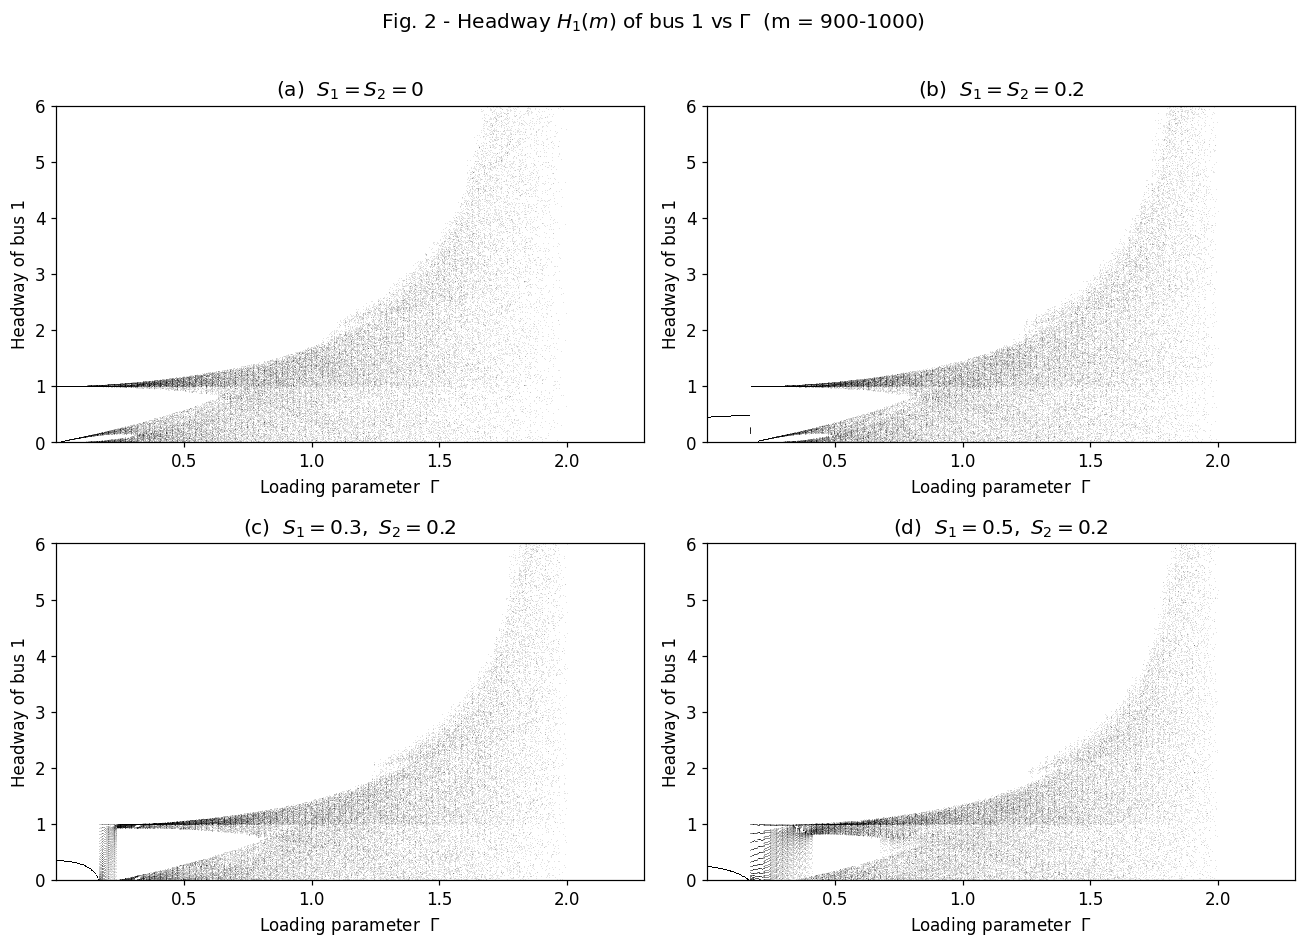

In [3]:
cases = [("(a)  $S_1=S_2=0$",          0.0, 0.0),
         ("(b)  $S_1=S_2=0.2$",        0.2, 0.2),
         ("(c)  $S_1=0.3,\\ S_2=0.2$", 0.3, 0.2),
         ("(d)  $S_1=0.5,\\ S_2=0.2$", 0.5, 0.2)]


def bifurcation(ax, s1, s2, g_min, g_max, n_g, title, ymax):
    X, Y = [], []
    for G in np.linspace(g_min, g_max, n_g):
        H, dv = simulate(G, s1, s2)
        if dv:
            continue
        X.extend([G] * len(H))
        Y.extend(H.tolist())
    ax.scatter(X, Y, s=0.12, c="k", marker=".", linewidths=0)
    ax.set_title(title)
    ax.set_xlabel("Loading parameter  $\\Gamma$")
    ax.set_ylabel("Headway of bus 1")
    ax.set_xlim(g_min, g_max + 0.3)
    ax.set_ylim(0, ymax)


fig, axes = plt.subplots(2, 2, figsize=(12, 8.5))
for ax, (name, s1, s2) in zip(axes.ravel(), cases):
    bifurcation(ax, s1, s2, 0.001, 2.0, 600, name, ymax=6)
fig.suptitle("Fig. 2 - Headway $H_1(m)$ of bus 1 vs $\\Gamma$  (m = 900-1000)", y=1.01)
fig.tight_layout()
plt.show()


## 4. Fig. 3 — zoom on $0 < \Gamma < 0.5$

The small-$\Gamma$ window resolves the transition points. For case (d) the points 1, 2, 3 are marked.

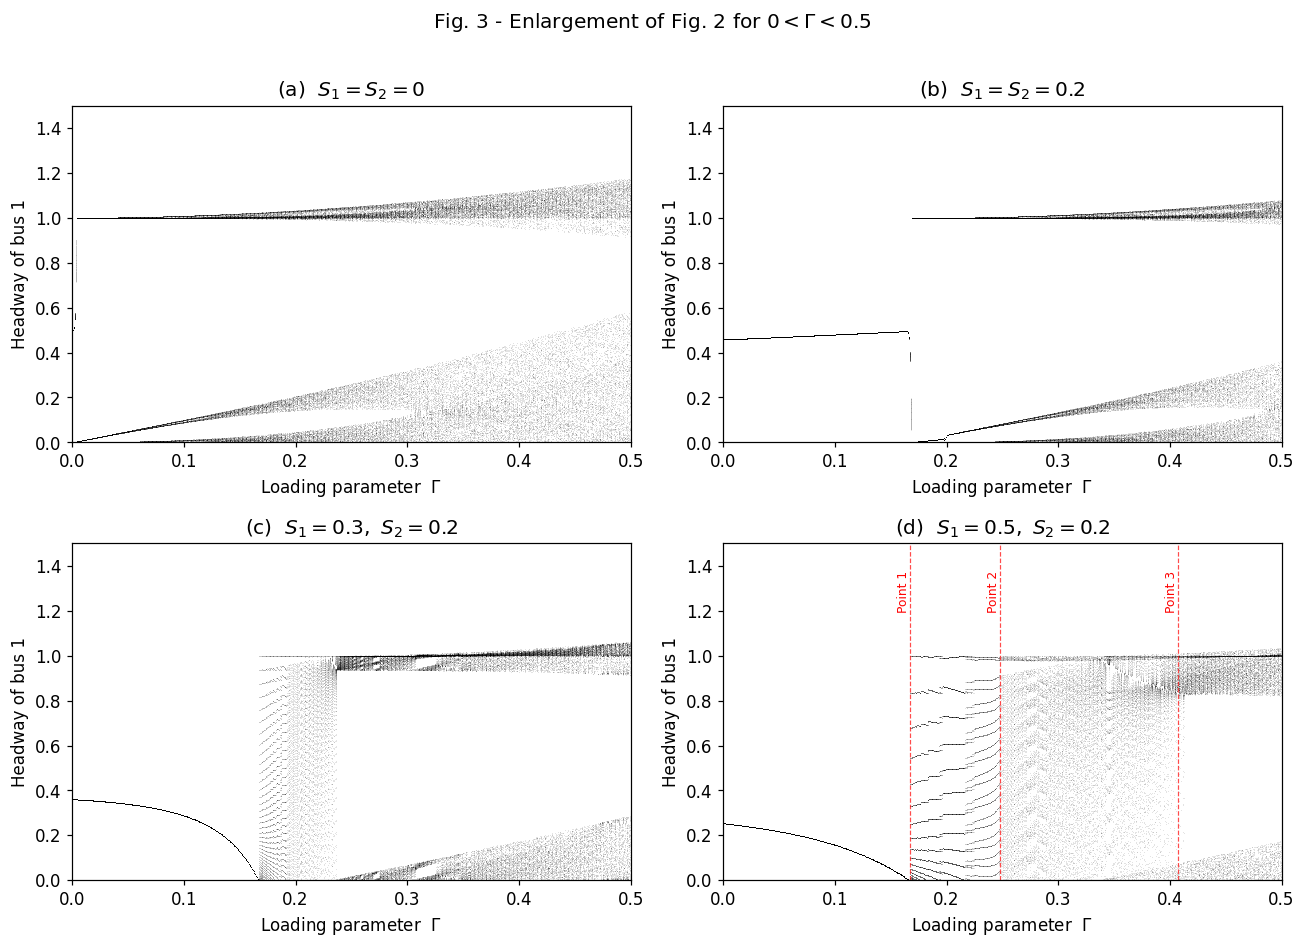

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8.5))
points_d = {"Point 1": 0.167, "Point 2": 0.248, "Point 3": 0.407}
for ax, (name, s1, s2) in zip(axes.ravel(), cases):
    bifurcation(ax, s1, s2, 0.001, 0.5, 700, name, ymax=1.5)
    ax.set_xlim(0, 0.5)
    if (s1, s2) == (0.5, 0.2):
        for lbl, gp in points_d.items():
            ax.axvline(gp, color="r", ls="--", lw=0.8, alpha=0.7)
            ax.text(gp, 1.38, lbl, rotation=90, va="top", ha="right", color="r", fontsize=8)
fig.suptitle("Fig. 3 - Enlargement of Fig. 2 for $0 < \\Gamma < 0.5$", y=1.01)
fig.tight_layout()
plt.show()


## 5. Return map (Fig. 6)

$H_1(m{+}1)$ vs $H_1(m)$ for case (d) at $\Gamma = 0.2, 0.3, 0.5, 0.8$. At $\Gamma=0.2$ the map collapses to 11 discrete points (period 11); larger $\Gamma$ give piecewise maps that generate chaos.

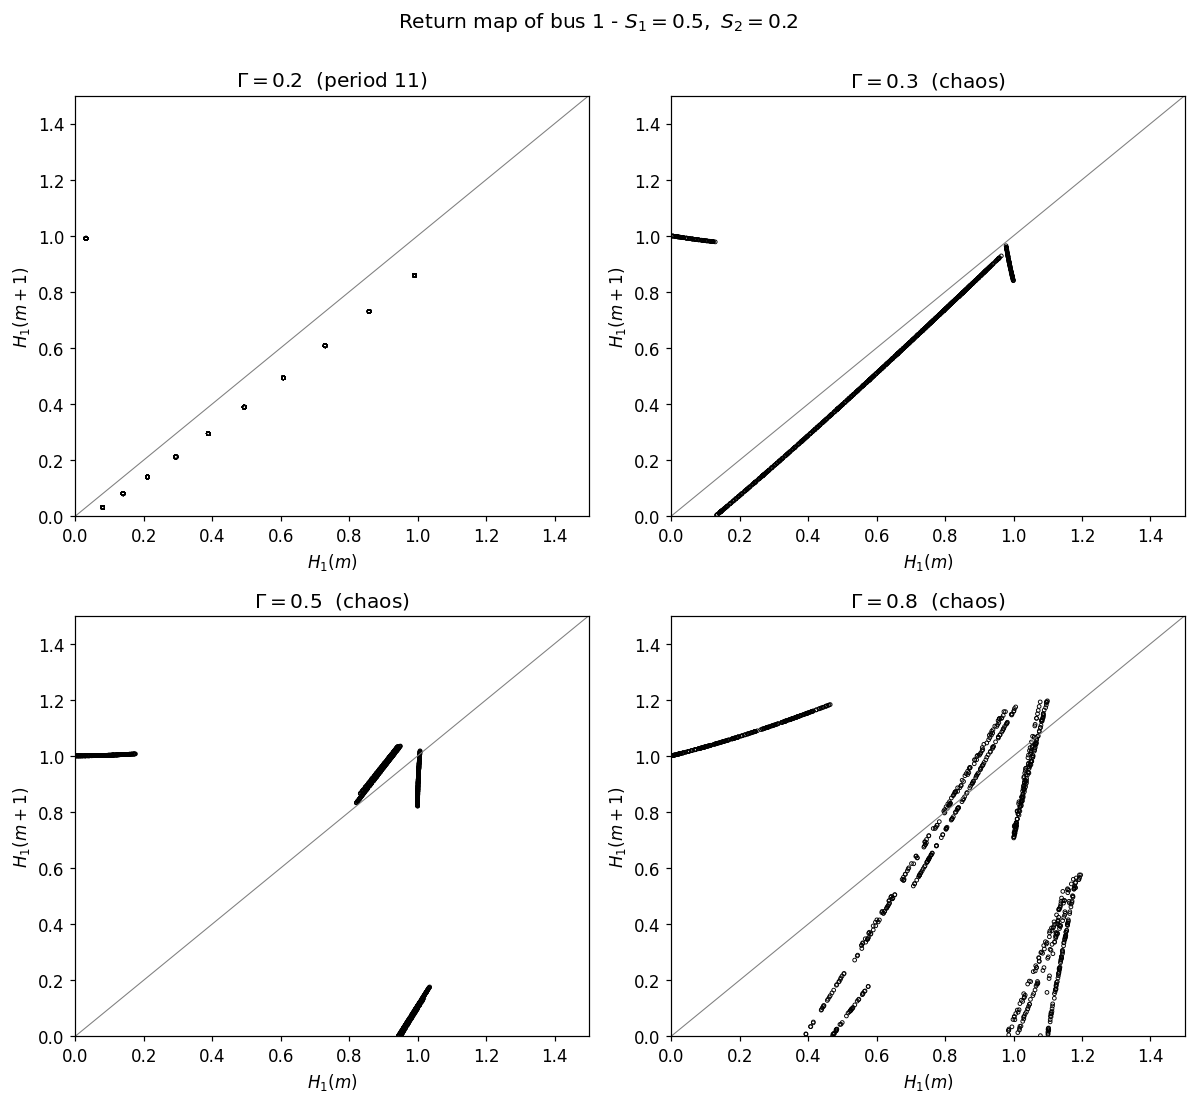

In [5]:
def return_map(Gamma, S1, S2, n_collect=1000):
    T = np.array([0.0, 0.5])
    S = np.array([S1, S2])
    tau_prev = -0.5
    trip = [0, 0]
    seq = []
    for _ in range(2 * (2000 + 10)):
        i = int(np.argmin(T))
        tau_i = T[i]
        H = tau_i - tau_prev
        if not np.isfinite(H) or H > 1e4:
            break
        trip[i] += 1
        if i == 0 and trip[0] > 1000:
            seq.append(H)
        T[i] = tau_i + Gamma * H + 1.0 / (1.0 + S[i] * H)
        tau_prev = tau_i
        if trip[0] > 1000 + n_collect:
            break
    seq = np.array(seq)
    return seq[:-1], seq[1:]


fig, axes = plt.subplots(2, 2, figsize=(11, 10))
for ax, G in zip(axes.ravel(), [0.2, 0.3, 0.5, 0.8]):
    x, y = return_map(G, 0.5, 0.2)
    ax.plot([0, 1.5], [0, 1.5], color="gray", lw=0.7)
    ax.scatter(x, y, s=6, facecolors="none", edgecolors="k", linewidths=0.6)
    ax.set_xlim(0, 1.5)
    ax.set_ylim(0, 1.5)
    ax.set_xlabel("$H_1(m)$")
    ax.set_ylabel("$H_1(m+1)$")
    ax.set_title(f"$\\Gamma={G}$  ({'period 11' if G == 0.2 else 'chaos'})")
fig.suptitle("Return map of bus 1 - $S_1=0.5,\\ S_2=0.2$", y=1.0)
fig.tight_layout()
plt.show()


## 6. Explanation of Fig. 2 & Fig. 3

### 6.1 How speedup damps headway oscillations

Each bus carries two opposing feedback loops in Eq. (5):

- **Positive (destabilizing):** a large headway accumulates more passengers, so the stop time $\Gamma H_i$ is longer, the bus falls further behind, and the headway grows even more. Left unchecked, one bus is caught and **overtaken** by the other, the bus order flips, and the headway jumps abruptly -> irregular motion.
- **Negative (stabilizing, from speedup):** the run term $1/(1+S_iH_i)$ **shrinks** as $H_i$ grows, so a late bus runs faster and pulls the headway back. Larger $S_i$ means a stronger restoring pull.

For small $\Gamma$ the negative loop wins and both buses converge to a **regular** state with constant headway (the map's fixed point has multiplier below 1). That is the flat region at the left of plots (b)-(d).

**Comparison across cases:**

- **(a) $S_1=S_2=0$:** no negative feedback at all, so there is **no regular region** — the headway already fluctuates at tiny $\Gamma$ (Fig. 3a clusters near ~0 and ~1, spreading with $\Gamma$). Chaos spans the whole range $0 < \Gamma < 2$.
- **(b) $S_1=S_2=0.2$:** a **regular region** appears for $\Gamma < 0.167$ with constant, evenly split headway ($H_1 \approx 0.46$). Speedup has **pushed the instability threshold** from $\Gamma=0$ up to $\Gamma=0.167$ — that is the damping. Past the threshold, symmetry makes the (b) spectrum for $0.167<\Gamma<0.5$ match (a) for $0<\Gamma<0.333$.
- **(c), (d) $S_1 \ne S_2$:** still regular up to $\Gamma=0.167$, but the two buses compensate **differently**, so their headways differ and the system routes through **periodic** then **chaotic** motion in a more intricate way. Fig. 3(c) differs markedly from Fig. 3(d): the $S_1{-}S_2$ asymmetry alone produces very complex motion.

### 6.2 Why larger $\Gamma$ produces irregular behavior

Raising $\Gamma$ raises the gain of the positive loop (each unit of headway costs more stop time). In sequence:

1. **$\Gamma < 0.167$ — regular:** stable fixed point, constant headway, no fluctuation.
2. **$\Gamma = 0.167$ (point 1) — regular -> periodic:** the fixed point loses stability and the orbit settles onto a finite cycle. At $\Gamma=0.2$ the return map is exactly **11 points** -> period-11.
3. **$0.167 < \Gamma < 0.248$ — period-adding bifurcations:** the period grows through a cascade.
4. **$\Gamma = 0.248$ (point 2) — onset of chaos:** the return map becomes a multi-valued piecewise map; the headway spectrum fills a continuous band — **deterministic chaos** with **no random noise**. This is the source of the irregular arrivals passengers experience.
5. **$\Gamma = 0.407$ (point 3):** a further dynamical transition reshapes the chaotic band.
6. **$\Gamma \to 2$ — divergence:** the positive loop dominates completely; the delay accumulates without bound and the headway (and tour time) **diverge**, so the schedule collapses. Hence chaos lives only in $0 < \Gamma < 2$.

### 6.3 Takeaways

- Speedup ($S_i > 0$) creates a **threshold** $\Gamma^\*$ below which buses run regularly and on time; larger $S_i$ raises $\Gamma^\*$, so chaos can be **controlled** with speed.
- Bus-to-bus **asymmetry** ($S_1 \ne S_2$) enriches the dynamics (periodic, period-adding, multi-band chaos).
- The irregular headway is **deterministic chaos** born from boarding + free passing, not randomness — so it is predictable and schedulable if $(\Gamma, S)$ is kept in the regular region.
